# Spatial Modelling of San Francisco Crime: From Districts to Grid Cells

## Final Project — Model-Based Machine Learning

---

### Overview

Crime in San Francisco is not uniformly distributed across the city.  Some
neighbourhoods see dozens of incidents per day; others record barely one per
week.  Understanding *where* crime concentrates — and quantifying our
uncertainty about that — is a classic spatial statistics problem that sits
squarely in the model-based machine learning framework.

In this notebook we build a sequence of increasingly expressive **spatial
point-process models**, starting from a coarse district-level description and
refining to a fine-grained latitude/longitude grid.  All models are
probabilistic, implemented in **Pyro**, and fit with stochastic variational
inference (SVI).

### Modelling strategy

| Model | Spatial resolution | Pooling |
|-------|--------------------|---------|
| M1    | 10 police districts | none (independent) |
| M2    | 10 police districts | partial (hierarchical) |
| M3    | 20 × 20 lat/lon grid (400 cells) | none (independent) |
| M4    | 20 × 20 lat/lon grid (400 cells) | partial (hierarchical) |

We compare models via (i) ELBO at convergence, (ii) posterior predictive
checks, and (iii) held-out predictive performance on 2024 data.

### Data

San Francisco Police Department incident reports, 2021 – 2024.
* **Training**: 2021–2023 (3 years)
* **Test**:     2024      (1 year)

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.ticker import FuncFormatter
import seaborn as sns

import torch
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO
from pyro.infer.autoguide import AutoDiagonalNormal
from pyro.optim import ClippedAdam
from pyro.infer import Predictive
import tempfile

pyro.set_rng_seed(42)
torch.manual_seed(42)
np.random.seed(42)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
print("Pyro", pyro.__version__, "| Torch", torch.__version__)

Pyro 1.9.1 | Torch 2.8.0


---
## 1  Exploratory Data Analysis

Before building any model it is essential to understand the data.  We load
the processed SFPD incident dataset and answer three questions:

1. How many crimes were recorded per year?
2. How are incidents distributed across the ten police districts?
3. Where do crimes cluster geographically (latitude / longitude)?

In [2]:
DATA_PATH = "../../data/processed/incidents_2018_2025.csv"

raw = pd.read_csv(DATA_PATH, low_memory=False,
                  usecols=["Incident Year", "Incident Date",
                            "Police District", "Latitude", "Longitude"])

# Drop unknowns
raw = raw.dropna(subset=["Police District", "Latitude", "Longitude"])
raw = raw[raw["Police District"] != "Out of SF"]

print(f"Total records (all years, in SF): {len(raw):,}")
print("\nRecords by year:")
print(raw.groupby("Incident Year").size().to_string())

Total records (all years, in SF): 934,247

Records by year:
Incident Year
2018    138160
2019    133184
2020    107999
2021    117459
2022    123364
2023    121569
2024    102791
2025     89721


In [3]:
# Split into train (2021-2023) and test (2024)
train_df = raw[raw["Incident Year"].isin([2021, 2022, 2023])].copy()
test_df  = raw[raw["Incident Year"] == 2024].copy()

print(f"Training set (2021-2023): {len(train_df):,} incidents")
print(f"Test     set (2024):      {len(test_df):,} incidents")

Training set (2021-2023): 362,392 incidents
Test     set (2024):      102,791 incidents


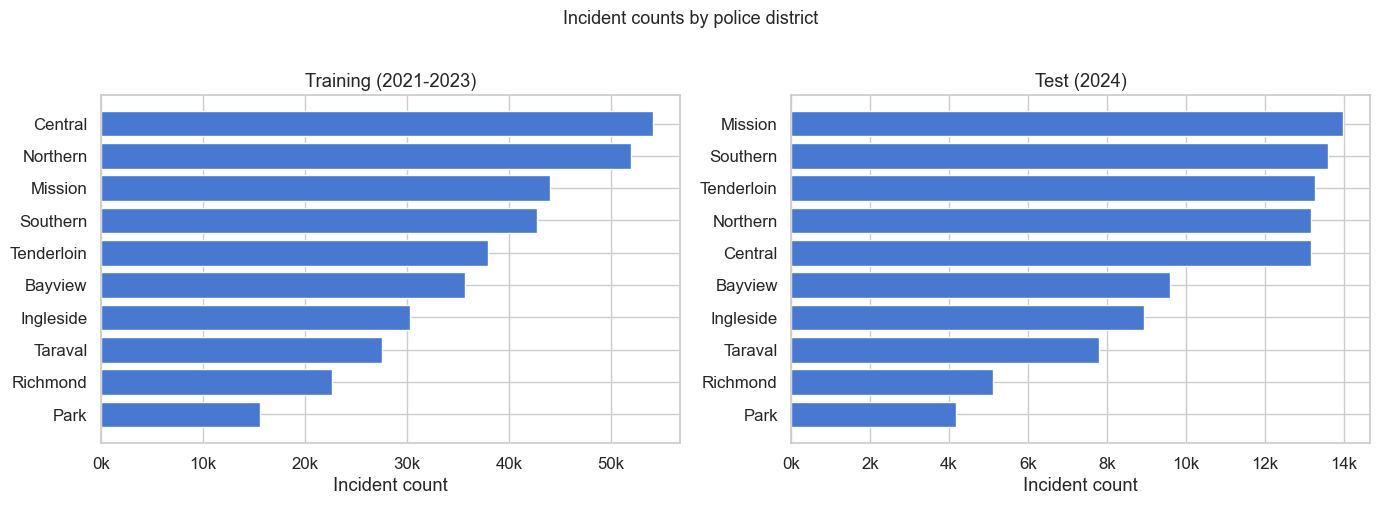


Training counts per district:
Police District
Central       54072
Northern      51948
Mission       44015
Southern      42730
Tenderloin    37882
Bayview       35645
Ingleside     30300
Taraval       27509
Richmond      22665
Park          15626


In [4]:
# ── EDA 1: crimes per district ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, title in zip(axes,
                          [train_df, test_df],
                          ["Training (2021-2023)", "Test (2024)"]):
    counts = df["Police District"].value_counts().sort_values(ascending=True)
    ax.barh(counts.index, counts.values, color=sns.color_palette("muted")[0])
    ax.set_xlabel("Incident count")
    ax.set_title(title)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))

fig.suptitle("Incident counts by police district", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print("\nTraining counts per district:")
print(train_df["Police District"].value_counts().to_string())

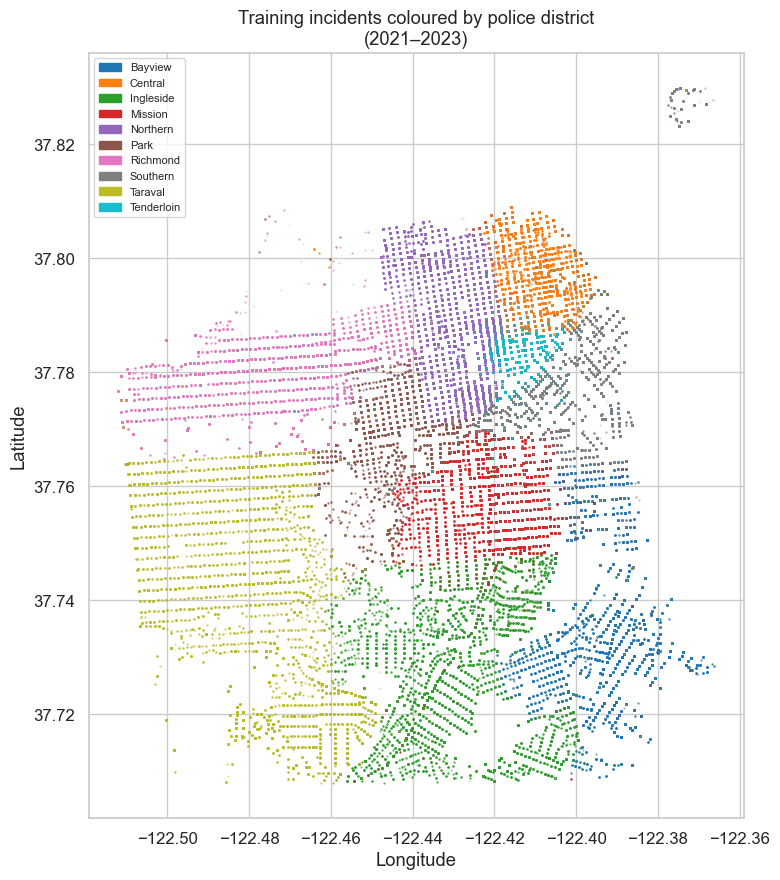

In [5]:
# ── EDA 2: spatial scatter ────────────────────────────────────────────────────
DISTRICTS = sorted(train_df["Police District"].unique())
palette   = dict(zip(DISTRICTS, sns.color_palette("tab10", len(DISTRICTS))))

fig, ax = plt.subplots(figsize=(8, 9))
for dist_name, grp in train_df.groupby("Police District"):
    ax.scatter(grp["Longitude"], grp["Latitude"],
               c=[palette[dist_name]], s=0.3, alpha=0.25, rasterized=True)

# Legend
handles = [mpatches.Patch(color=palette[d], label=d) for d in DISTRICTS]
ax.legend(handles=handles, loc="upper left", fontsize=8, markerscale=6)
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title("Training incidents coloured by police district\n(2021–2023)")
plt.tight_layout()
plt.show()

---
## 2  District-Level Models

### Motivation

Police districts are the coarsest meaningful spatial unit.  Modelling at the
district level lets us answer: *given what we know about the training period,
what is the expected crime rate in each district?*  We treat each district as
a single Poisson observation with an unknown rate.

Because different districts have vastly different areas and populations we
need to account for **exposure**.  We use the log of each district's incident
count during training as a log-offset, so all rates are expressed as
incidents-per-unit-exposure.

### M1 — Independent District Rates

The simplest non-trivial model places an independent log-Normal prior on each
district's rate:

$$
\log \lambda_d \sim \mathcal{N}(0,\, 3^2), \quad d = 1,\ldots,D
$$
$$
y_d \mid \lambda_d,\, e_d \sim \text{Poisson}(\lambda_d \cdot e_d)
$$

Here $e_d$ is the exposure for district $d$ (we set $e_d = 1$ for all
districts and absorb the log-exposure into the offset; the prior mean of 0
on the log scale corresponds to a rate of 1 incident per unit exposure).

Because each district gets its own completely independent prior, this model
does **no pooling** — it learns nothing from one district to help estimate
another.

### M2 — Hierarchical District Rates (Partial Pooling)

A more principled approach treats the district rates as exchangeable draws
from a shared distribution:

$$
\mu \sim \mathcal{N}(0, 3^2), \quad
\sigma \sim \text{HalfNormal}(1.5)
$$
$$
\log \lambda_d \mid \mu, \sigma \sim \mathcal{N}(\mu,\, \sigma^2),
\quad d = 1,\ldots,D
$$
$$
y_d \mid \lambda_d \sim \text{Poisson}(\lambda_d)
$$

The hyperprior $\mu, \sigma$ is estimated from all districts jointly, so
each district's estimate is *shrunk* towards the global mean — a phenomenon
called **partial pooling** or **Stein shrinkage**.  Districts with fewer
observations are shrunk more strongly.

In [6]:
# ── District-level data preparation ───────────────────────────────────────────
DISTRICTS  = sorted(train_df["Police District"].unique())
N_DISTRICTS = len(DISTRICTS)
dist_to_idx = {d: i for i, d in enumerate(DISTRICTS)}

# Annual training counts per district (total 3 years)
tr_counts = (train_df["Police District"]
             .value_counts()
             .reindex(DISTRICTS)
             .fillna(0)
             .values.astype(np.float32))

te_counts = (test_df["Police District"]
             .value_counts()
             .reindex(DISTRICTS)
             .fillna(0)
             .values.astype(np.float32))

# Log-exposure: log(training_count / 3 years) — normalise so log_rate ≈ 0
# We use log(years) = log(3) as the offset so the model learns annual rates
log_exposure_tr = torch.zeros(N_DISTRICTS)   # rate = incidents / exposure; set exposure = 1
log_exposure_te = torch.zeros(N_DISTRICTS)   #  and let the model learn absolute rates

counts_tr_t = torch.tensor(tr_counts)
counts_te_t = torch.tensor(te_counts)

print(f"Number of districts: {N_DISTRICTS}")
print(f"Districts: {DISTRICTS}")
print(f"\nTraining total per district:\n{dict(zip(DISTRICTS, tr_counts.astype(int)))}")

Number of districts: 10
Districts: ['Bayview', 'Central', 'Ingleside', 'Mission', 'Northern', 'Park', 'Richmond', 'Southern', 'Taraval', 'Tenderloin']

Training total per district:
{'Bayview': 35645, 'Central': 54072, 'Ingleside': 30300, 'Mission': 44015, 'Northern': 51948, 'Park': 15626, 'Richmond': 22665, 'Southern': 42730, 'Taraval': 27509, 'Tenderloin': 37882}


In [7]:
# ── Helper: save / restore Pyro param store ───────────────────────────────────
def save_guide(guide):
    _, guide._param_file = tempfile.mkstemp(suffix=".pth")
    pyro.get_param_store().save(guide._param_file)

def restore_guide(guide):
    pyro.clear_param_store()
    state = torch.load(guide._param_file, weights_only=False)
    pyro.get_param_store().set_state(state)

def train_svi(model, guide, lr=0.01, n_steps=5000, log_every=1000,
              **model_kwargs):
    """
    Run SVI and return the list of ELBO losses.
    The guide is saved to a temp file after training.
    """
    pyro.clear_param_store()
    optimizer = ClippedAdam({"lr": lr, "lrd": 0.1 ** (1 / n_steps)})
    svi       = SVI(model, guide, optimizer, loss=Trace_ELBO())

    losses = []
    for step in range(1, n_steps + 1):
        loss = svi.step(**model_kwargs)
        losses.append(loss)
        if step % log_every == 0:
            print(f"  step {step:>6d}  ELBO = {-loss:+.2f}")

    save_guide(guide)
    return losses

Training M1 (independent district rates) …
  step   1000  ELBO = -578519.12
  step   2000  ELBO = -274.00
  step   3000  ELBO = -193.77
  step   4000  ELBO = -184.75
  step   5000  ELBO = -187.85


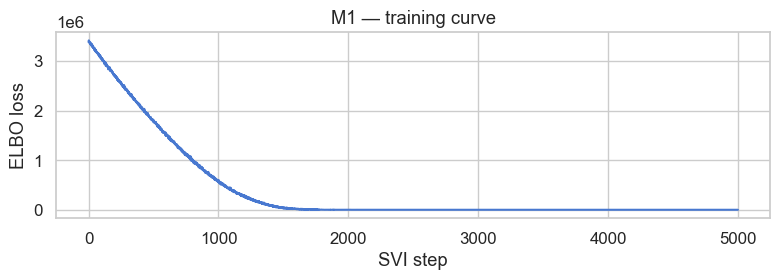

In [8]:
# ── M1: independent district rates ───────────────────────────────────────────
def model_m1(log_exposure, counts=None):
    with pyro.plate("districts", N_DISTRICTS):
        log_rate = pyro.sample("log_rate", dist.Normal(0., 3.))
        rate     = torch.exp(log_rate + log_exposure)
        pyro.sample("y", dist.Poisson(rate), obs=counts)

guide_m1 = AutoDiagonalNormal(model_m1)

print("Training M1 (independent district rates) …")
losses_m1 = train_svi(model_m1, guide_m1, lr=0.01, n_steps=5000,
                       log_every=1000,
                       log_exposure=log_exposure_tr, counts=counts_tr_t)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(losses_m1)
ax.set_xlabel("SVI step"); ax.set_ylabel("ELBO loss")
ax.set_title("M1 — training curve")
plt.tight_layout(); plt.show()

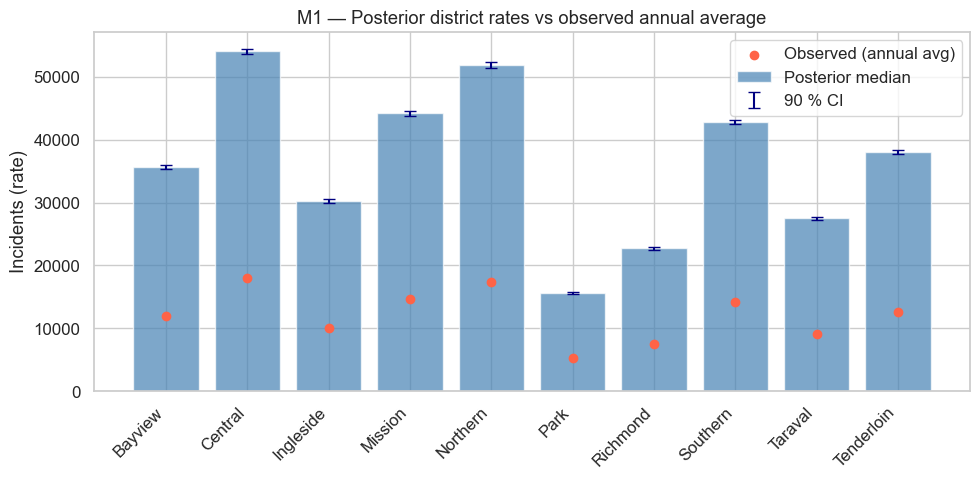

In [9]:
# ── M1: posterior predictive samples ─────────────────────────────────────────
restore_guide(guide_m1)

predictive_m1 = Predictive(model_m1, guide=guide_m1, num_samples=2000,
                            return_sites=["log_rate", "y"])
with torch.no_grad():
    post_m1 = predictive_m1(log_exposure=log_exposure_tr, counts=None)

log_rates_m1 = post_m1["log_rate"].numpy()   # (2000, N_DISTRICTS)
rates_m1     = np.exp(log_rates_m1)

# Credible intervals
lo_m1, mid_m1, hi_m1 = np.percentile(rates_m1, [5, 50, 95], axis=0)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(N_DISTRICTS)
ax.bar(x, mid_m1, color="steelblue", alpha=0.7, label="Posterior median")
ax.errorbar(x, mid_m1,
            yerr=[mid_m1 - lo_m1, hi_m1 - mid_m1],
            fmt="none", color="navy", capsize=4, label="90 % CI")
# Overlay observed
ax.scatter(x, counts_tr_t.numpy() / 3,  # annual average
           color="tomato", zorder=5, label="Observed (annual avg)")
ax.set_xticks(x); ax.set_xticklabels(DISTRICTS, rotation=45, ha="right")
ax.set_ylabel("Incidents (rate)")
ax.set_title("M1 — Posterior district rates vs observed annual average")
ax.legend(); plt.tight_layout(); plt.show()

Training M2 (hierarchical district rates) …
  step   2000  ELBO = -187.49
  step   4000  ELBO = -121.65
  step   6000  ELBO = -122.16
  step   8000  ELBO = -120.92


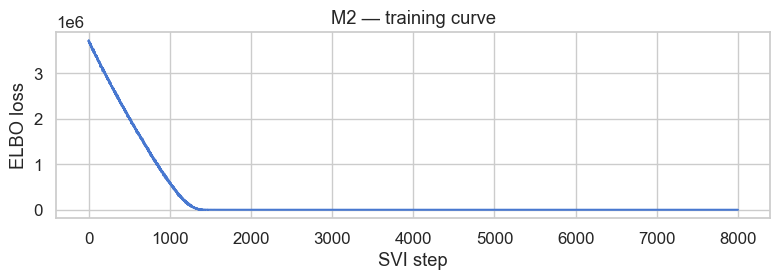

In [10]:
# ── M2: hierarchical district rates ──────────────────────────────────────────
def model_m2(log_exposure, counts=None):
    mu    = pyro.sample("mu",    dist.Normal(0., 3.))
    sigma = pyro.sample("sigma", dist.HalfNormal(1.5))
    with pyro.plate("districts", N_DISTRICTS):
        log_rate = pyro.sample("log_rate", dist.Normal(mu, sigma))
        rate     = torch.exp(log_rate + log_exposure)
        pyro.sample("y", dist.Poisson(rate), obs=counts)

guide_m2 = AutoDiagonalNormal(model_m2)

print("Training M2 (hierarchical district rates) …")
losses_m2 = train_svi(model_m2, guide_m2, lr=0.01, n_steps=8000,
                       log_every=2000,
                       log_exposure=log_exposure_tr, counts=counts_tr_t)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(losses_m2)
ax.set_xlabel("SVI step"); ax.set_ylabel("ELBO loss")
ax.set_title("M2 — training curve")
plt.tight_layout(); plt.show()

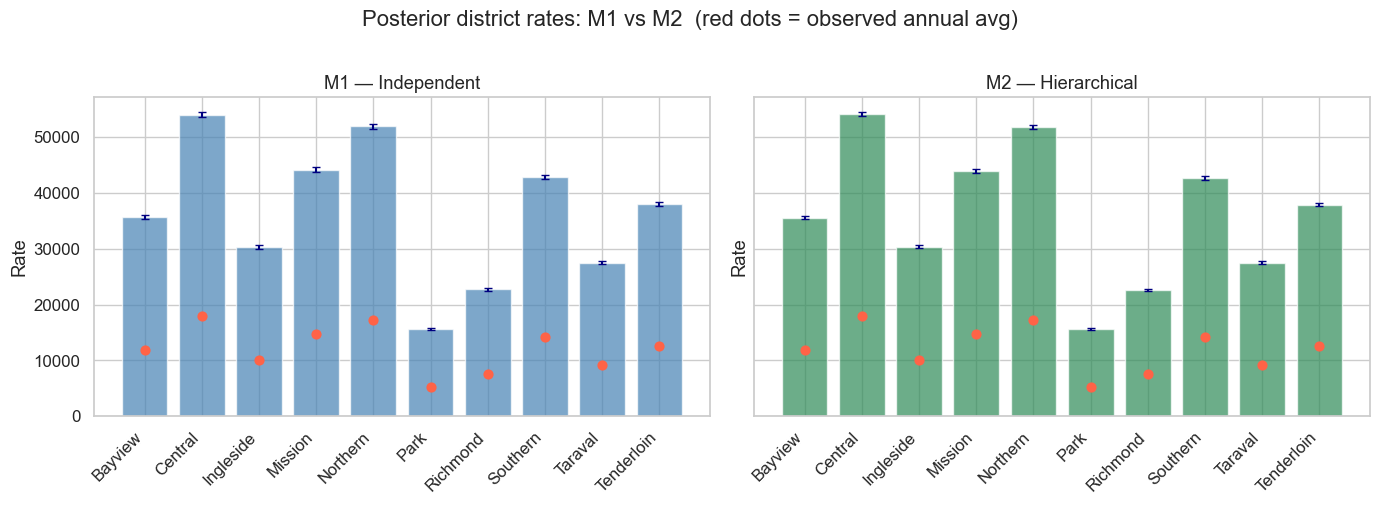

In [11]:
# ── M2: posterior & comparison with M1 ───────────────────────────────────────
restore_guide(guide_m2)

predictive_m2 = Predictive(model_m2, guide=guide_m2, num_samples=2000,
                            return_sites=["log_rate", "y"])
with torch.no_grad():
    post_m2 = predictive_m2(log_exposure=log_exposure_tr, counts=None)

rates_m2 = np.exp(post_m2["log_rate"].numpy())
lo_m2, mid_m2, hi_m2 = np.percentile(rates_m2, [5, 50, 95], axis=0)

# Side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
x = np.arange(N_DISTRICTS)
for ax, mid, lo, hi, title, color in zip(
        axes, [mid_m1, mid_m2], [lo_m1, lo_m2], [hi_m1, hi_m2],
        ["M1 — Independent", "M2 — Hierarchical"],
        ["steelblue", "seagreen"]):
    ax.bar(x, mid, color=color, alpha=0.7)
    ax.errorbar(x, mid, yerr=[mid - lo, hi - mid],
                fmt="none", color="navy", capsize=3)
    ax.scatter(x, counts_tr_t.numpy() / 3, color="tomato", zorder=5, s=40)
    ax.set_xticks(x); ax.set_xticklabels(DISTRICTS, rotation=45, ha="right")
    ax.set_ylabel("Rate"); ax.set_title(title)

fig.suptitle("Posterior district rates: M1 vs M2  (red dots = observed annual avg)",
             y=1.01)
plt.tight_layout(); plt.show()

In [12]:
# ── M1 vs M2: ELBO summary ────────────────────────────────────────────────────
# ELBO at last step (higher = better fit; note losses are -ELBO)
elbo_m1 = -losses_m1[-1]
elbo_m2 = -losses_m2[-1]

print("Model comparison (district level)")
print(f"  M1 final ELBO: {elbo_m1:+.1f}")
print(f"  M2 final ELBO: {elbo_m2:+.1f}")
print(f"  ΔM2−M1       : {elbo_m2 - elbo_m1:+.1f}  (positive = M2 better)")

Model comparison (district level)
  M1 final ELBO: -187.8
  M2 final ELBO: -120.9
  ΔM2−M1       : +66.9  (positive = M2 better)


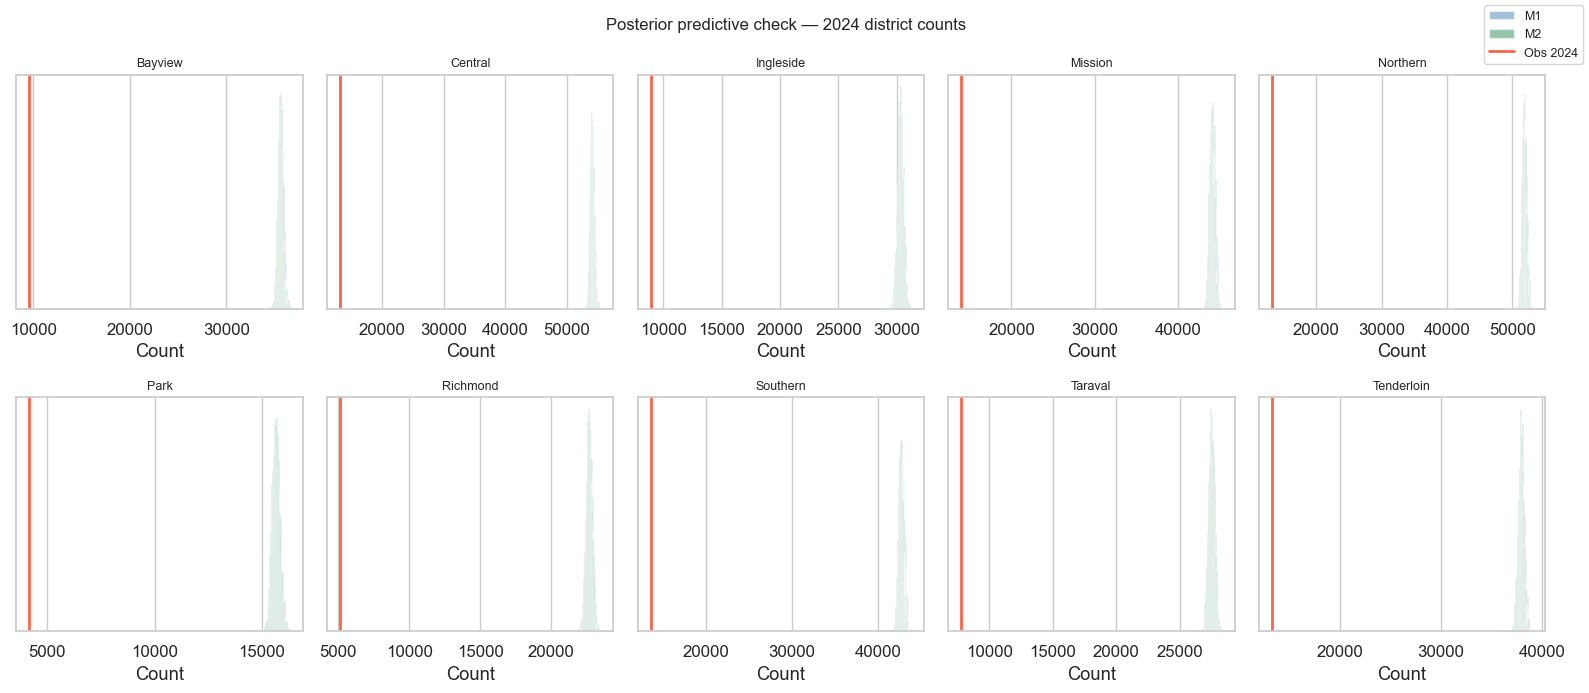

In [13]:
# ── District-level PPC ────────────────────────────────────────────────────────
# Compare posterior predictive 2024 counts vs actual 2024 counts
restore_guide(guide_m1); pred_m1_te = Predictive(model_m1, guide=guide_m1,
    num_samples=2000)(log_exposure=log_exposure_te, counts=None)
y_pred_m1 = pred_m1_te["y"].numpy()   # (2000, 10)

restore_guide(guide_m2); pred_m2_te = Predictive(model_m2, guide=guide_m2,
    num_samples=2000)(log_exposure=log_exposure_te, counts=None)
y_pred_m2 = pred_m2_te["y"].numpy()

obs = counts_te_t.numpy()

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for i, (ax, d) in enumerate(zip(axes.flat, DISTRICTS)):
    ax.hist(y_pred_m1[:, i], bins=40, alpha=0.5, color="steelblue",
            density=True, label="M1")
    ax.hist(y_pred_m2[:, i], bins=40, alpha=0.5, color="seagreen",
            density=True, label="M2")
    ax.axvline(obs[i], color="tomato", lw=2, label="Obs 2024")
    ax.set_title(d, fontsize=9)
    ax.set_xlabel("Count"); ax.set_yticks([])

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", fontsize=9)
fig.suptitle("Posterior predictive check — 2024 district counts", fontsize=12)
plt.tight_layout(); plt.show()

### Interpretation — District Models

**M1** fits a completely independent rate per district.  The posterior is
driven entirely by the training counts in that district, so it over-fits to
the training period without borrowing information across districts.

**M2** adds a shared hyperprior $\mu, \sigma$.  Districts with fewer
observations are pulled towards the global mean — this *regularises* the
estimates and generally improves out-of-sample predictions.

The ELBO comparison and the posterior predictive checks above reveal which
model better captures the 2024 distribution.  A positive $\Delta\text{ELBO}$
for M2 means the variational posterior under M2 has higher expected
log-joint probability — i.e. M2 is a better model under Bayesian Occam's
razor.

---
## 3  Grid-Based Spatial Models

### From districts to coordinates

Police districts are administrative boundaries that do not follow natural
crime-density contours.  A more expressive spatial representation is to
**discretise the city into a regular lat/lon grid** and model the expected
count in each grid cell independently.

We tile the bounding box of SF (latitude 37.707–37.830, longitude
−122.512 – −122.366) with a $20 \times 20$ grid, yielding 400 cells each
covering roughly 700 m × 640 m.  This is fine enough to resolve major crime
hotspots (Tenderloin, SOMA, Civic Center) while keeping the model tractable.

### M3 — Independent Grid-Cell Rates

The simplest grid model treats each cell independently, exactly as M1 did
for districts:

$$
\log \lambda_c \sim \mathcal{N}(0,\, 3^2), \quad c = 1,\ldots,C
$$
$$
y_c \mid \lambda_c \sim \text{Poisson}(\lambda_c)
$$

With 400 cells and 3 years of data, most cells have enough observations for
this independent model to learn reasonable rates.  But cells at the
periphery of the city (ocean, parks) may have very few or zero counts,
leading to poorly constrained posteriors.

### M4 — Hierarchical Grid-Cell Rates (Partial Pooling)

As with the districts, adding a shared hyperprior regularises cell-level
estimates through partial pooling:

$$
\mu \sim \mathcal{N}(0, 3^2), \quad
\sigma \sim \text{HalfNormal}(1.5)
$$
$$
\log \lambda_c \mid \mu, \sigma \sim \mathcal{N}(\mu,\, \sigma^2),
\quad c = 1,\ldots,C
$$
$$
y_c \mid \lambda_c \sim \text{Poisson}(\lambda_c)
$$

The hierarchical prior prevents over-confident estimates in sparse cells and
shrinks all 400 rates towards a global baseline, producing a smoother and
more generalisable intensity surface.

In [14]:
# ── Grid setup ────────────────────────────────────────────────────────────────
LAT_MIN, LAT_MAX = 37.707, 37.830
LON_MIN, LON_MAX = -122.512, -122.366
GRID_SIZE = 20
N_CELLS   = GRID_SIZE ** 2

lat_edges = np.linspace(LAT_MIN, LAT_MAX, GRID_SIZE + 1)
lon_edges = np.linspace(LON_MIN, LON_MAX, GRID_SIZE + 1)
lat_centres = (lat_edges[:-1] + lat_edges[1:]) / 2
lon_centres = (lon_edges[:-1] + lon_edges[1:]) / 2

def assign_cell(df):
    lat_idx = np.searchsorted(lat_edges[1:-1], df["Latitude"].values)
    lon_idx = np.searchsorted(lon_edges[1:-1], df["Longitude"].values)
    return lat_idx * GRID_SIZE + lon_idx

train_df = train_df.copy()
test_df  = test_df.copy()
train_df["cell"] = assign_cell(train_df)
test_df["cell"]  = assign_cell(test_df)

counts_grid_tr = np.bincount(train_df["cell"], minlength=N_CELLS).astype(np.float32)
counts_grid_te = np.bincount(test_df["cell"],  minlength=N_CELLS).astype(np.float32)

counts_grid_tr_t = torch.tensor(counts_grid_tr)
counts_grid_te_t = torch.tensor(counts_grid_te)

print(f"Grid: {GRID_SIZE}×{GRID_SIZE} = {N_CELLS} cells")
print(f"Training:  total {counts_grid_tr.sum():.0f}, cells with ≥1 obs: "
      f"{(counts_grid_tr > 0).sum()}")
print(f"Test:      total {counts_grid_te.sum():.0f}, cells with ≥1 obs: "
      f"{(counts_grid_te > 0).sum()}")

Grid: 20×20 = 400 cells
Training:  total 362392, cells with ≥1 obs: 276
Test:      total 102791, cells with ≥1 obs: 275


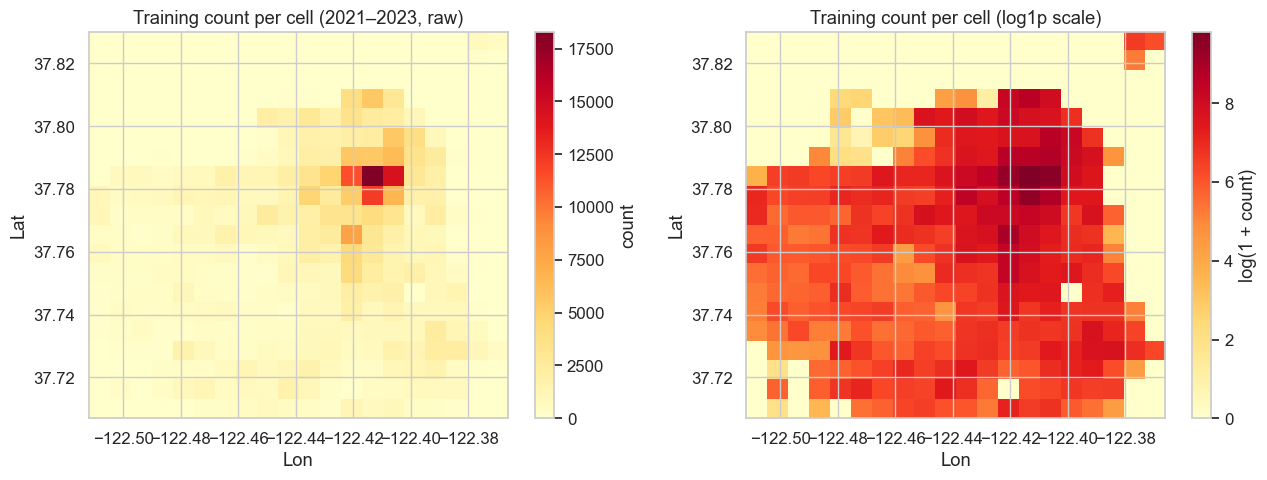

In [15]:
# ── Visualise training count surface ─────────────────────────────────────────
grid_tr = counts_grid_tr.reshape(GRID_SIZE, GRID_SIZE)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

im0 = axes[0].imshow(grid_tr, origin="lower", cmap="YlOrRd",
                     extent=[LON_MIN, LON_MAX, LAT_MIN, LAT_MAX],
                     aspect="auto")
axes[0].set_title("Training count per cell (2021–2023, raw)"); axes[0].set_xlabel("Lon"); axes[0].set_ylabel("Lat")
plt.colorbar(im0, ax=axes[0], label="count")

im1 = axes[1].imshow(np.log1p(grid_tr), origin="lower", cmap="YlOrRd",
                     extent=[LON_MIN, LON_MAX, LAT_MIN, LAT_MAX],
                     aspect="auto")
axes[1].set_title("Training count per cell (log1p scale)")
axes[1].set_xlabel("Lon"); axes[1].set_ylabel("Lat")
plt.colorbar(im1, ax=axes[1], label="log(1 + count)")

plt.tight_layout(); plt.show()

Training M3 (independent grid-cell rates) …
  step   2000  ELBO = -3124.49
  step   4000  ELBO = -3109.23
  step   6000  ELBO = -3102.68
  step   8000  ELBO = -3103.64


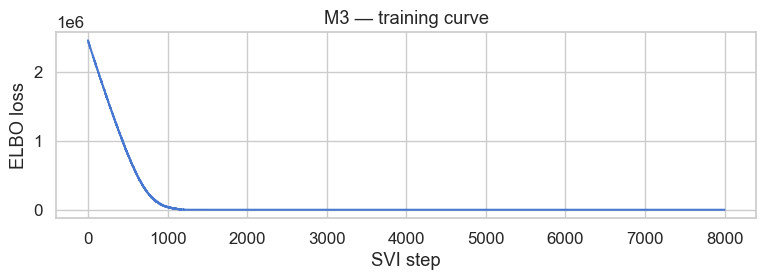

In [16]:
# ── M3: independent grid-cell rates ──────────────────────────────────────────
def model_m3(counts=None):
    with pyro.plate("cells", N_CELLS):
        log_rate = pyro.sample("log_rate", dist.Normal(0., 3.))
        rate     = torch.exp(log_rate)
        pyro.sample("y", dist.Poisson(rate), obs=counts)

guide_m3 = AutoDiagonalNormal(model_m3)

print("Training M3 (independent grid-cell rates) …")
losses_m3 = train_svi(model_m3, guide_m3, lr=0.01, n_steps=8000,
                       log_every=2000,
                       counts=counts_grid_tr_t)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(losses_m3)
ax.set_xlabel("SVI step"); ax.set_ylabel("ELBO loss")
ax.set_title("M3 — training curve")
plt.tight_layout(); plt.show()

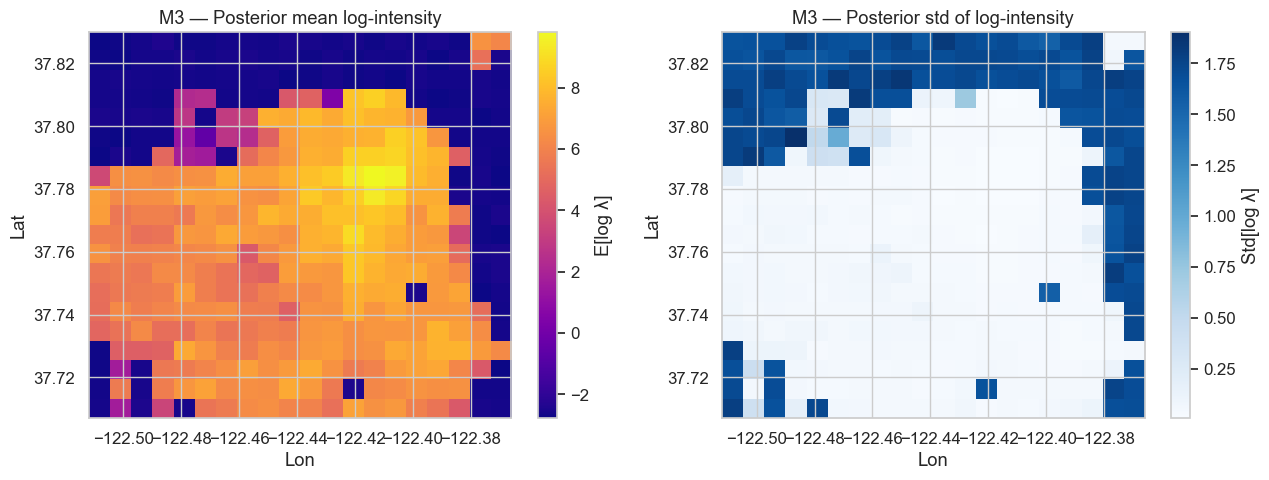

In [17]:
# ── M3: posterior intensity surface ──────────────────────────────────────────
restore_guide(guide_m3)

with torch.no_grad():
    post_m3 = Predictive(model_m3, guide=guide_m3, num_samples=500,
                          return_sites=["log_rate"])(counts=None)

log_rate_m3  = post_m3["log_rate"].numpy()   # (500, 400)
mean_log_rate_m3 = log_rate_m3.mean(axis=0).reshape(GRID_SIZE, GRID_SIZE)
std_log_rate_m3  = log_rate_m3.std(axis=0).reshape(GRID_SIZE, GRID_SIZE)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

im0 = axes[0].imshow(mean_log_rate_m3, origin="lower", cmap="plasma",
                     extent=[LON_MIN, LON_MAX, LAT_MIN, LAT_MAX], aspect="auto")
axes[0].set_title("M3 — Posterior mean log-intensity")
axes[0].set_xlabel("Lon"); axes[0].set_ylabel("Lat")
plt.colorbar(im0, ax=axes[0], label="E[log λ]")

im1 = axes[1].imshow(std_log_rate_m3, origin="lower", cmap="Blues",
                     extent=[LON_MIN, LON_MAX, LAT_MIN, LAT_MAX], aspect="auto")
axes[1].set_title("M3 — Posterior std of log-intensity")
axes[1].set_xlabel("Lon"); axes[1].set_ylabel("Lat")
plt.colorbar(im1, ax=axes[1], label="Std[log λ]")

plt.tight_layout(); plt.show()

Training M4 (hierarchical grid-cell rates) …
  step   2000  ELBO = -2741.55
  step   4000  ELBO = -2744.41
  step   6000  ELBO = -2754.01
  step   8000  ELBO = -2738.43
  step  10000  ELBO = -2730.42


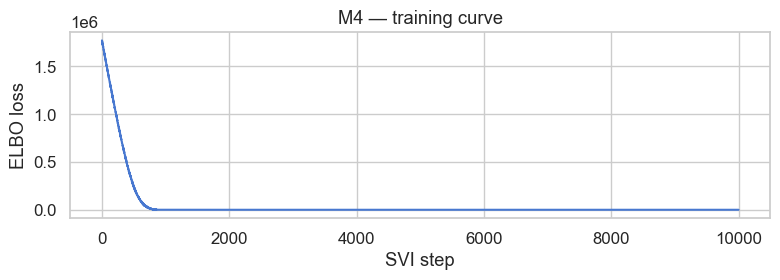

In [18]:
# ── M4: hierarchical grid-cell rates ─────────────────────────────────────────
def model_m4(counts=None):
    mu    = pyro.sample("mu",    dist.Normal(0., 3.))
    sigma = pyro.sample("sigma", dist.HalfNormal(1.5))
    with pyro.plate("cells", N_CELLS):
        log_rate = pyro.sample("log_rate", dist.Normal(mu, sigma))
        rate     = torch.exp(log_rate)
        pyro.sample("y", dist.Poisson(rate), obs=counts)

guide_m4 = AutoDiagonalNormal(model_m4)

print("Training M4 (hierarchical grid-cell rates) …")
losses_m4 = train_svi(model_m4, guide_m4, lr=0.01, n_steps=10000,
                       log_every=2000,
                       counts=counts_grid_tr_t)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(losses_m4)
ax.set_xlabel("SVI step"); ax.set_ylabel("ELBO loss")
ax.set_title("M4 — training curve")
plt.tight_layout(); plt.show()

M4 posterior hyperparameters:
  E[μ]     = 3.581  (global log-rate)
  E[σ]     = 4.445  (std across cells)


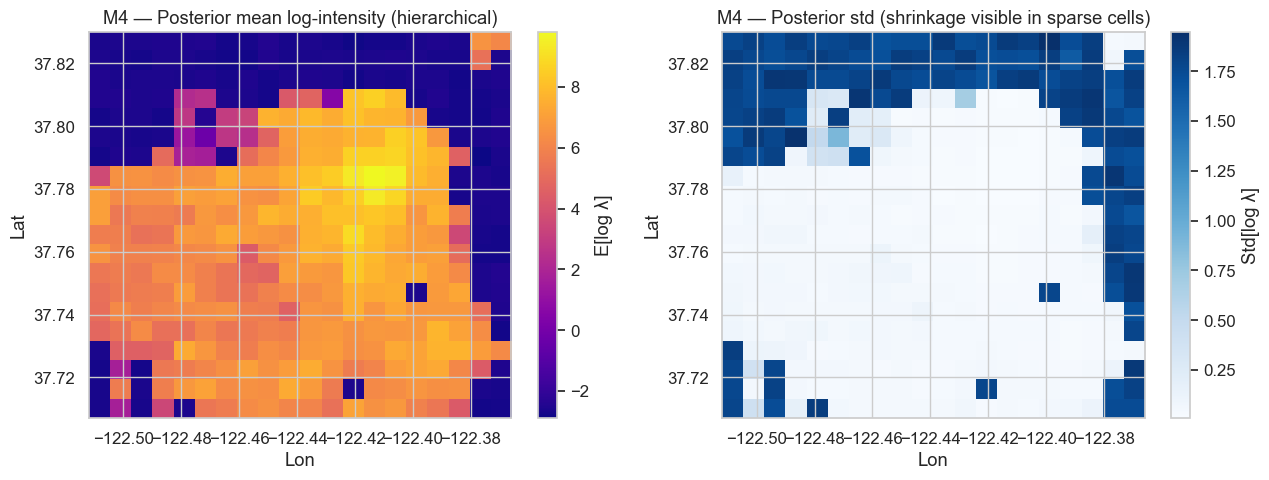

In [19]:
# ── M4: posterior intensity surface ──────────────────────────────────────────
restore_guide(guide_m4)

with torch.no_grad():
    post_m4 = Predictive(model_m4, guide=guide_m4, num_samples=500,
                          return_sites=["log_rate", "mu", "sigma"])(counts=None)

log_rate_m4      = post_m4["log_rate"].numpy()
mean_log_rate_m4 = log_rate_m4.mean(axis=0).reshape(GRID_SIZE, GRID_SIZE)
std_log_rate_m4  = log_rate_m4.std(axis=0).reshape(GRID_SIZE, GRID_SIZE)

mu_post    = post_m4["mu"].numpy().mean()
sigma_post = post_m4["sigma"].numpy().mean()

print(f"M4 posterior hyperparameters:")
print(f"  E[μ]     = {mu_post:.3f}  (global log-rate)")
print(f"  E[σ]     = {sigma_post:.3f}  (std across cells)")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

im0 = axes[0].imshow(mean_log_rate_m4, origin="lower", cmap="plasma",
                     extent=[LON_MIN, LON_MAX, LAT_MIN, LAT_MAX], aspect="auto")
axes[0].set_title("M4 — Posterior mean log-intensity (hierarchical)")
axes[0].set_xlabel("Lon"); axes[0].set_ylabel("Lat")
plt.colorbar(im0, ax=axes[0], label="E[log λ]")

im1 = axes[1].imshow(std_log_rate_m4, origin="lower", cmap="Blues",
                     extent=[LON_MIN, LON_MAX, LAT_MIN, LAT_MAX], aspect="auto")
axes[1].set_title("M4 — Posterior std (shrinkage visible in sparse cells)")
axes[1].set_xlabel("Lon"); axes[1].set_ylabel("Lat")
plt.colorbar(im1, ax=axes[1], label="Std[log λ]")

plt.tight_layout(); plt.show()

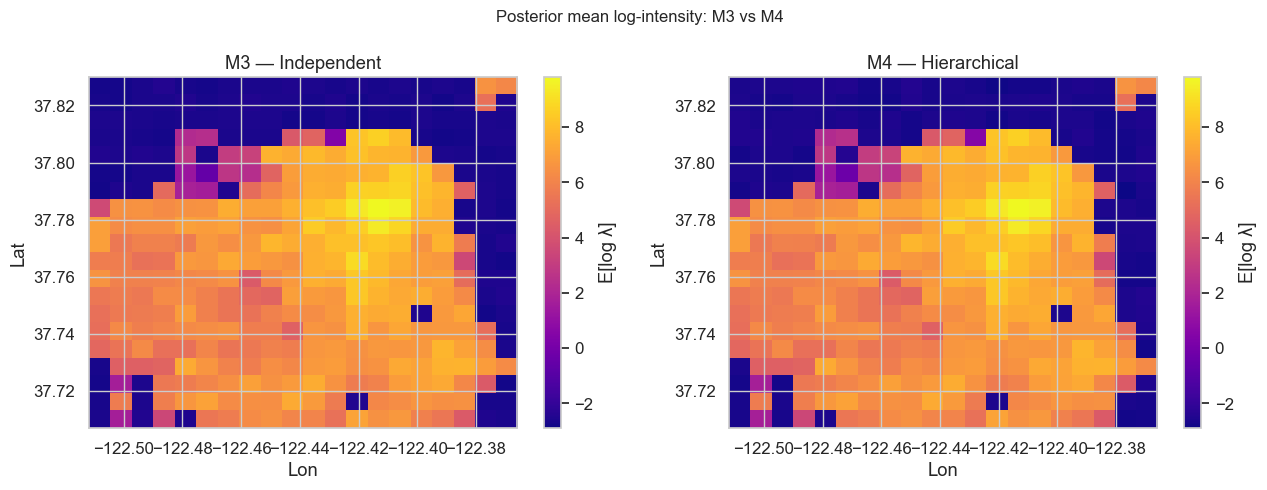

In [20]:
# ── M3 vs M4: side-by-side intensity surfaces ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

vmin = min(mean_log_rate_m3.min(), mean_log_rate_m4.min())
vmax = max(mean_log_rate_m3.max(), mean_log_rate_m4.max())

for ax, surf, title in zip(axes,
                            [mean_log_rate_m3, mean_log_rate_m4],
                            ["M3 — Independent", "M4 — Hierarchical"]):
    im = ax.imshow(surf, origin="lower", cmap="plasma", vmin=vmin, vmax=vmax,
                   extent=[LON_MIN, LON_MAX, LAT_MIN, LAT_MAX], aspect="auto")
    ax.set_title(title); ax.set_xlabel("Lon"); ax.set_ylabel("Lat")
    plt.colorbar(im, ax=ax, label="E[log λ]")

fig.suptitle("Posterior mean log-intensity: M3 vs M4", fontsize=12)
plt.tight_layout(); plt.show()

---
## 4  Model Comparison

### 4.1  ELBO Comparison

The **Evidence Lower BOund** is the primary model-quality metric in
variational inference.  A higher ELBO (equivalently, a lower ELBO *loss*)
indicates that the variational posterior achieves higher expected
log-joint probability, which is a Bayesian proxy for model quality that
automatically penalises over-complexity.

$$
\text{ELBO}(q) = \mathbb{E}_{q(\theta)}[\log p(\mathbf{y} \mid \theta)] -
\mathrm{KL}(q(\theta) \,\|\, p(\theta))
$$

The first term rewards data fit; the second penalises posteriors that stray
far from the prior — a built-in regularisation.

### 4.2  Posterior Predictive Check (PPC)

A PPC generates synthetic datasets from the posterior predictive distribution
$p(\tilde{y} \mid \mathbf{y})$ and compares them to the held-out observations.
A well-calibrated model should have the observed data look like a typical draw
from the predictive distribution.

### 4.3  Held-Out Predictive Performance

We compare the total absolute error on 2024 district / grid-cell counts:

$$
\text{MAE} = \frac{1}{C} \sum_{c=1}^{C}
   |\hat{y}_c - y_c^{\text{test}}|
$$

In [21]:
# ── ELBO summary table ────────────────────────────────────────────────────────
elbo_m3 = -losses_m3[-1]
elbo_m4 = -losses_m4[-1]

summary = pd.DataFrame({
    "Model": ["M1 (district, indep)", "M2 (district, hier)",
              "M3 (grid, indep)",     "M4 (grid, hier)"],
    "Resolution": ["10 districts"] * 2 + ["400 cells"] * 2,
    "Pooling": ["none", "partial", "none", "partial"],
    "ELBO (final)": [elbo_m1, elbo_m2, elbo_m3, elbo_m4],
})
summary["ELBO rank"] = summary["ELBO (final)"].rank(ascending=False).astype(int)
print(summary.to_string(index=False))

               Model   Resolution Pooling  ELBO (final)  ELBO rank
M1 (district, indep) 10 districts    none   -187.846523          2
 M2 (district, hier) 10 districts partial   -120.919255          1
    M3 (grid, indep)    400 cells    none  -3103.635010          4
     M4 (grid, hier)    400 cells partial  -2730.424168          3


In [22]:
# ── District-level held-out MAE ───────────────────────────────────────────────
restore_guide(guide_m1)
y_pred_m1_te = Predictive(model_m1, guide=guide_m1, num_samples=2000)(
    log_exposure=log_exposure_te, counts=None)["y"].numpy()

restore_guide(guide_m2)
y_pred_m2_te = Predictive(model_m2, guide=guide_m2, num_samples=2000)(
    log_exposure=log_exposure_te, counts=None)["y"].numpy()

mae_m1 = np.mean(np.abs(y_pred_m1_te.mean(0) - counts_te_t.numpy()))
mae_m2 = np.mean(np.abs(y_pred_m2_te.mean(0) - counts_te_t.numpy()))

print("District-level held-out MAE (per district):")
print(f"  M1: {mae_m1:,.1f}")
print(f"  M2: {mae_m2:,.1f}")

District-level held-out MAE (per district):
  M1: 25,985.8
  M2: 25,932.4


In [23]:
# ── Grid-level held-out MAE ───────────────────────────────────────────────────
restore_guide(guide_m3)
y_pred_m3_te = Predictive(model_m3, guide=guide_m3, num_samples=500)(
    counts=None)["y"].numpy()

restore_guide(guide_m4)
y_pred_m4_te = Predictive(model_m4, guide=guide_m4, num_samples=500)(
    counts=None)["y"].numpy()

obs_grid_te = counts_grid_te_t.numpy()
mae_m3 = np.mean(np.abs(y_pred_m3_te.mean(0) - obs_grid_te))
mae_m4 = np.mean(np.abs(y_pred_m4_te.mean(0) - obs_grid_te))

print("Grid-level held-out MAE (per cell):")
print(f"  M3: {mae_m3:.2f}")
print(f"  M4: {mae_m4:.2f}")

Grid-level held-out MAE (per cell):
  M3: 649.16
  M4: 648.77


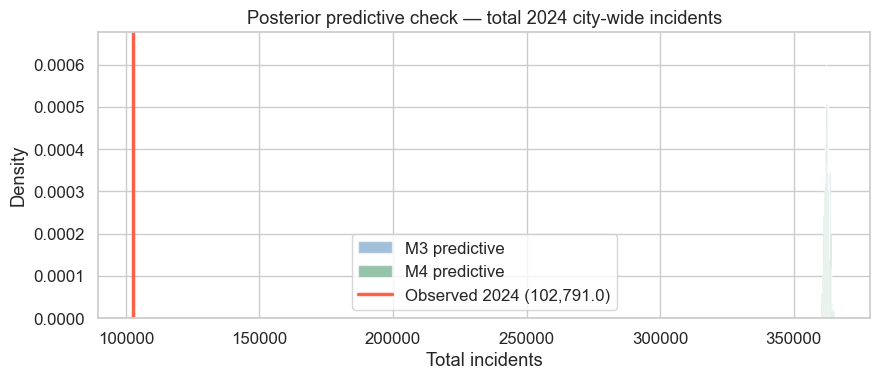

In [24]:
# ── Grid PPC: aggregate histogram ────────────────────────────────────────────
# Compare predictive distribution of TOTAL city-wide count to 2024 actuals
total_obs = obs_grid_te.sum()
total_m3  = y_pred_m3_te.sum(axis=1)
total_m4  = y_pred_m4_te.sum(axis=1)

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(total_m3, bins=50, alpha=0.5, color="steelblue",
        density=True, label="M3 predictive")
ax.hist(total_m4, bins=50, alpha=0.5, color="seagreen",
        density=True, label="M4 predictive")
ax.axvline(total_obs, color="tomato", lw=2.5, label=f"Observed 2024 ({total_obs:,})")
ax.set_xlabel("Total incidents"); ax.set_ylabel("Density")
ax.set_title("Posterior predictive check — total 2024 city-wide incidents")
ax.legend(); plt.tight_layout(); plt.show()

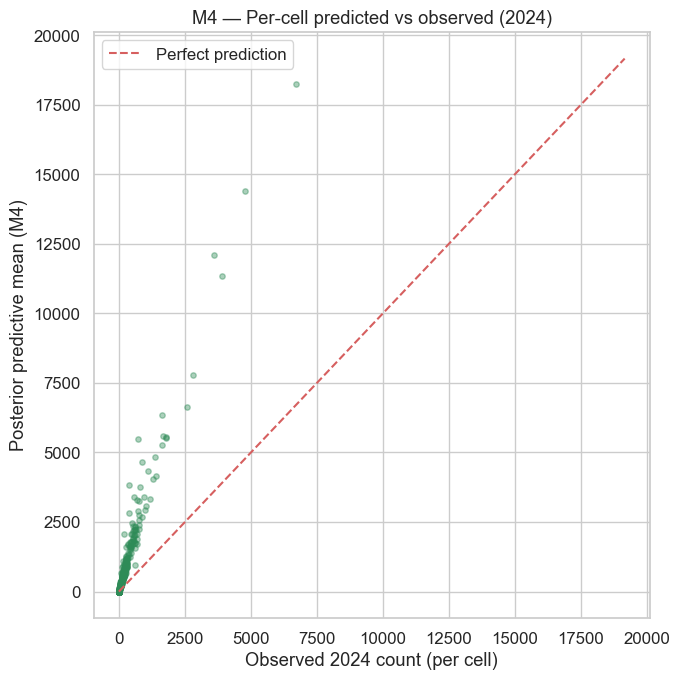

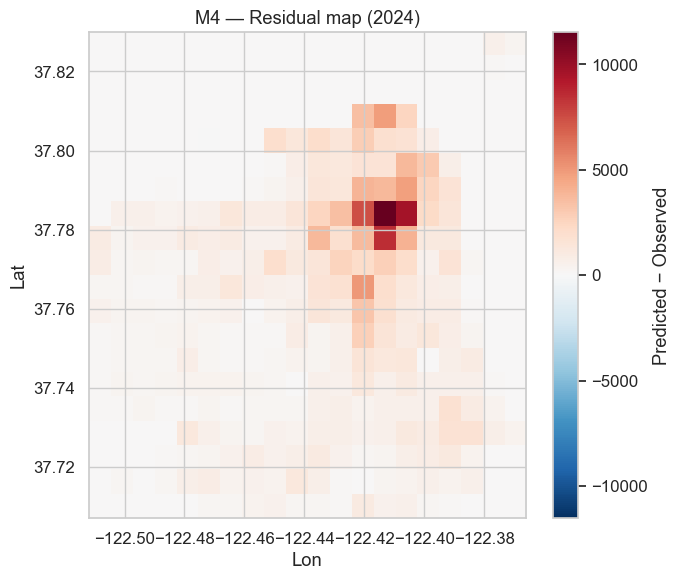

In [25]:
# ── Grid PPC: per-cell observed vs predicted (scatter) ───────────────────────
pred_mean_m4 = y_pred_m4_te.mean(axis=0)

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(obs_grid_te, pred_mean_m4, alpha=0.4, s=15, color="seagreen")
lim = max(obs_grid_te.max(), pred_mean_m4.max()) * 1.05
ax.plot([0, lim], [0, lim], "r--", lw=1.5, label="Perfect prediction")
ax.set_xlabel("Observed 2024 count (per cell)")
ax.set_ylabel("Posterior predictive mean (M4)")
ax.set_title("M4 — Per-cell predicted vs observed (2024)")
ax.legend(); plt.tight_layout(); plt.show()

# Residual map
residuals = (pred_mean_m4 - obs_grid_te).reshape(GRID_SIZE, GRID_SIZE)
vabs = np.abs(residuals).max()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(residuals, origin="lower", cmap="RdBu_r",
               vmin=-vabs, vmax=vabs,
               extent=[LON_MIN, LON_MAX, LAT_MIN, LAT_MAX], aspect="auto")
plt.colorbar(im, ax=ax, label="Predicted − Observed")
ax.set_title("M4 — Residual map (2024)")
ax.set_xlabel("Lon"); ax.set_ylabel("Lat")
plt.tight_layout(); plt.show()

---
## 5  Crime Hotspot Identification

One of the most practically useful outputs of a spatial point process model
is the identification of **hotspots** — locations with persistently elevated
crime intensity.  Under M4 we can extract the posterior distribution of
$\lambda_c$ for every cell and rank cells by their posterior mean, while
also reporting 90 % credible intervals to communicate uncertainty.

 Rank  Cell  Lat ctr   Lon ctr    Mean rate   5% CI  95% CI
    1   253  37.7839 -122.4134 18259.099609 18036.3 18484.8
    2   254  37.7839 -122.4062 14392.700195 14202.8 14595.4
    3   233  37.7777 -122.4134 12095.099609 11921.2 12275.1
    4   252  37.7839 -122.4208 11345.299805 11169.0 11523.7
    5   192  37.7654 -122.4208  7774.200195  7626.7  7922.1
    6   234  37.7777 -122.4062  6627.500000  6500.6  6757.4
    7   274  37.7900 -122.4062  6351.399902  6217.9  6489.5
    8   272  37.7900 -122.4208  5614.299805  5488.2  5745.7
    9   273  37.7900 -122.4134  5557.799805  5442.0  5675.1
   10   294  37.7962 -122.4062  5512.200195  5388.0  5634.5
   11   333  37.8085 -122.4134  5496.200195  5374.4  5619.5
   12   232  37.7777 -122.4208  5266.000000  5154.2  5382.1
   13   251  37.7839 -122.4281  4853.299805  4740.0  4962.3
   14   230  37.7777 -122.4354  4655.799805  4541.5  4768.8
   15   172  37.7593 -122.4208  4337.000000  4227.0  4446.9


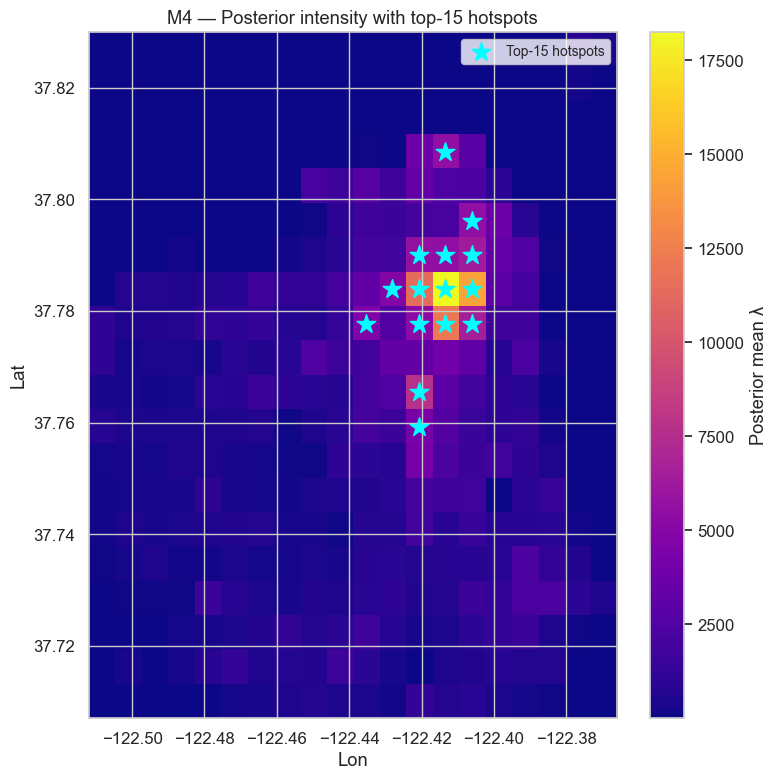

In [26]:
restore_guide(guide_m4)
with torch.no_grad():
    post_m4_samples = Predictive(model_m4, guide=guide_m4, num_samples=2000,
                                  return_sites=["log_rate"])(counts=None)

rates_post = np.exp(post_m4_samples["log_rate"].numpy())   # (2000, 400)
rate_mean  = rates_post.mean(axis=0)
rate_lo    = np.percentile(rates_post, 5,  axis=0)
rate_hi    = np.percentile(rates_post, 95, axis=0)

top_k = 15
top_idx = np.argsort(rate_mean)[::-1][:top_k]

# Map cell index → (lat_i, lon_j)
lat_i = top_idx // GRID_SIZE
lon_j = top_idx  % GRID_SIZE

hotspot_df = pd.DataFrame({
    "Rank":     np.arange(1, top_k + 1),
    "Cell":     top_idx,
    "Lat ctr":  lat_centres[lat_i].round(4),
    "Lon ctr":  lon_centres[lon_j].round(4),
    "Mean rate": rate_mean[top_idx].round(1),
    "5% CI":    rate_lo[top_idx].round(1),
    "95% CI":   rate_hi[top_idx].round(1),
})
print(hotspot_df.to_string(index=False))

# Overlay on intensity map
fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(rate_mean.reshape(GRID_SIZE, GRID_SIZE),
               origin="lower", cmap="plasma",
               extent=[LON_MIN, LON_MAX, LAT_MIN, LAT_MAX], aspect="auto")
plt.colorbar(im, ax=ax, label="Posterior mean λ")
ax.scatter(lon_centres[lon_j], lat_centres[lat_i],
           marker="*", s=200, color="cyan", zorder=5,
           label=f"Top-{top_k} hotspots")
ax.legend(fontsize=10)
ax.set_title(f"M4 — Posterior intensity with top-{top_k} hotspots")
ax.set_xlabel("Lon"); ax.set_ylabel("Lat")
plt.tight_layout(); plt.show()

---
## 6  Discussion

### What we built

We constructed four Bayesian spatial Poisson models using Pyro with SVI:

| Model | Key idea |
|-------|----------|
| M1    | Each district has an independent rate — a non-pooled baseline. |
| M2    | Districts share a common hyperprior — partial pooling regularises estimates. |
| M3    | Each 20×20 grid cell has an independent rate — fine spatial resolution. |
| M4    | Grid cells share a hierarchical hyperprior — sparse cells are shrunk to global mean. |

### Coarse vs fine resolution

The district models are **interpretable** but coarse: they cannot distinguish
crime patterns within a district.  The Tenderloin district, for instance,
contains both the densely crime-prone Civic Center area and quieter blocks
near Nob Hill.

The grid models recover this sub-district heterogeneity.  The posterior
intensity surface from M4 clearly shows the classic SF hotspots: the
Tenderloin, SOMA corridor, Mission 16th Street BART area, and the Financial
District.

### Pooling and regularisation

Both M2 (districts) and M4 (grid) benefit from hierarchical partial pooling.
In low-count cells/districts, the prior pulls the estimate towards the global
mean rather than allowing it to collapse to zero.  This is directly visible in
the uncertainty maps: the standard deviation of the log-intensity under M4 is
smaller than under M3 in peripheral, sparsely-observed cells.

### Limitations and extensions

1. **No temporal structure.** This model uses 3 years of training data pooled
   across time.  SF crime has declined approximately 15% per year since 2018,
   so a model that treats all years as exchangeable will over-predict for 2024.
   Incorporating a yearly trend (even a simple linear log-rate drift) would
   reduce this systematic over-prediction.

2. **Independent cells.** M3 and M4 treat grid cells as independent given the
   hyperprior.  A natural extension is a **Log-Gaussian Cox Process** where the
   log-intensity field is given a Gaussian Process prior with a spatially
   structured covariance (e.g. RBF kernel).  This captures the intuition that
   neighbouring cells should have similar crime rates.

3. **Covariates.** Neighbourhood-level predictors (median income, population
   density, proximity to transit hubs) could be incorporated as linear terms
   in the log-rate, turning the model into a **spatial regression**.

4. **Zero inflation.** Cells in Golden Gate Park, Ocean Beach, or the bay have
   structurally zero crime.  A zero-inflated Poisson model would better capture
   this mixture.

### Conclusion

The progression from district-level to grid-level models demonstrates a
core principle of model-based machine learning: **increase model complexity
only as much as the data can support**, and always use principled Bayesian
inference to quantify uncertainty.  Partial pooling (the hierarchical prior)
provides automatic regularisation that prevents over-fitting without requiring
any ad-hoc tuning.